<a href="https://colab.research.google.com/github/NikitaS-13/AI-CHATBOT-WITH-NLP/blob/main/NikitaTask.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score


In [ ]:
# Step 1: Data Loading and Initial EDA

file_path = '/content/people (2).csv'

try:
    df = pd.read_csv(file_path)
    print("DataFrame loaded successfully.")
except FileNotFoundError:
    print(f"Error: The file '{file_path}' was not found. Please upload it or check the path.")
    exit()

print("\n--- Initial EDA ---")
print("Shape of the dataset:", df.shape)
print("\nColumn data types:")
print(df.info())
print("\nFirst 5 rows of the dataset:")
print(df.head())
print("\nDescriptive statistics:")
print(df.describe(include='all'))

DataFrame loaded successfully.

--- Initial EDA ---
Shape of the dataset: (14999, 10)

Column data types:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfactoryLevel      14999 non-null  float64
 1   lastEvaluation         14999 non-null  float64
 2   numberOfProjects       14999 non-null  int64  
 3   avgMonthlyHours        14999 non-null  int64  
 4   timeSpent.company      14999 non-null  int64  
 5   workAccident           14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotionInLast5years  14999 non-null  int64  
 8   dept                   14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB
None

First 5 rows of the dataset:
   satisfactoryLevel  lastEvaluation  numberOfProjects  avgMonth

In [ ]:
# Step 2: Preprocessing and Feature Engineering
# The 'salary' column is categorical but has an ordinal nature. Let's map it to numerical values.

print("\nUnique values in 'salary' column before mapping:", df['salary'].unique())

salary_map = {'low': 1, 'medium': 2, 'high': 3}
df['salary'] = df['salary'].map(salary_map)
print("\n'salary' column has been mapped to numerical values.")

# Drop rows where salary mapping resulted in NaN (if any)
df.dropna(subset=['salary'], inplace=True)
print(f"\nDataFrame shape after dropping rows with missing salary values: {df.shape}")


Unique values in 'salary' column before mapping: ['low' 'medium' 'high']

'salary' column has been mapped to numerical values.

DataFrame shape after dropping rows with missing salary values: (14999, 10)


In [ ]:
# Step 3: Descriptive Analysis
print("\n--- Descriptive Analysis ---")

# Highest experienced department wise
# [cite_start]'timeSpent.company' represents years spent at the company[cite: 1].
print("\nHighest experienced department-wise:")
highest_experience = df.groupby('dept')['timeSpent.company'].mean().sort_values(ascending=False)
print(highest_experience)

# Highest salary department-wise
print("\nHighest salary department-wise:")
highest_salary = df.groupby('dept')['salary'].max().sort_values(ascending=False)
print(highest_salary)

# Satisfactory level department-wise (highest/lowest)
print("\nSatisfactory level department-wise (average):")
satisfactory_level = df.groupby('dept')['satisfactoryLevel'].mean().sort_values(ascending=False)
print(satisfactory_level)

# Department wise low salary employees
print("\nDepartment-wise number of low salary employees:")
low_salary_employees = df[df['salary'] == 1]['dept'].value_counts()
print(low_salary_employees)

# Department wise projects
print("\nDepartment-wise average number of projects:")
avg_projects = df.groupby('dept')['numberOfProjects'].mean().sort_values(ascending=False)
print(avg_projects)

# Department wise last evaluation
print("\nDepartment-wise average last evaluation:")
avg_last_evaluation = df.groupby('dept')['lastEvaluation'].mean().sort_values(ascending=False)
print(avg_last_evaluation)

# Department wise left
# This shows the number of employees who left the company per department.
print("\nDepartment-wise number of employees who left:")
left_employees = df[df['left'] == 1]['dept'].value_counts()
print(left_employees)



--- Descriptive Analysis ---

Highest experienced department-wise:
dept
management     4.303175
marketing      3.569930
sales          3.534058
accounting     3.522816
product_mng    3.475610
IT             3.468623
technical      3.411397
support        3.393001
RandD          3.367217
hr             3.355886
Name: timeSpent.company, dtype: float64

Highest salary department-wise:
dept
IT             3
RandD          3
accounting     3
hr             3
management     3
marketing      3
product_mng    3
sales          3
support        3
technical      3
Name: salary, dtype: int64

Satisfactory level department-wise (average):
dept
management     0.621349
RandD          0.619822
product_mng    0.619634
marketing      0.618601
support        0.618300
IT             0.618142
sales          0.614447
technical      0.607897
hr             0.598809
accounting     0.582151
Name: satisfactoryLevel, dtype: float64

Department-wise number of low salary employees:
dept
sales          2099
techni


--- Relationship Analysis & Visualization ---


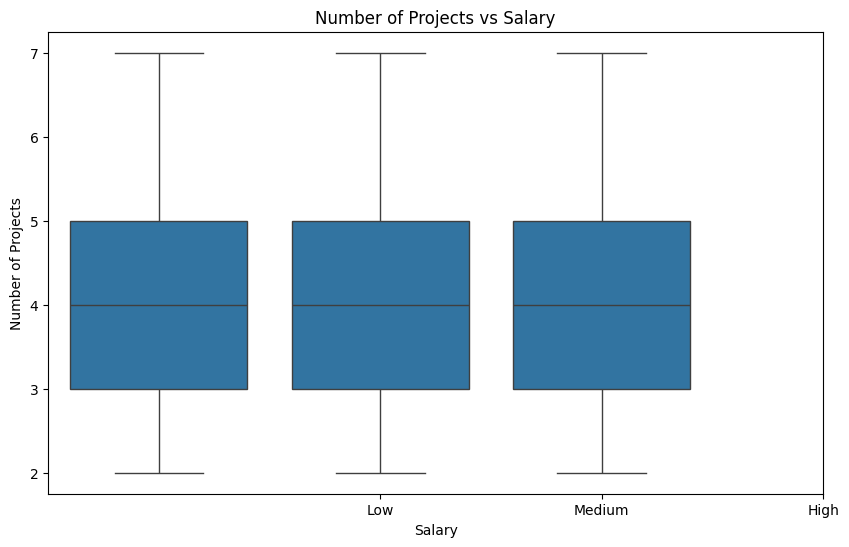

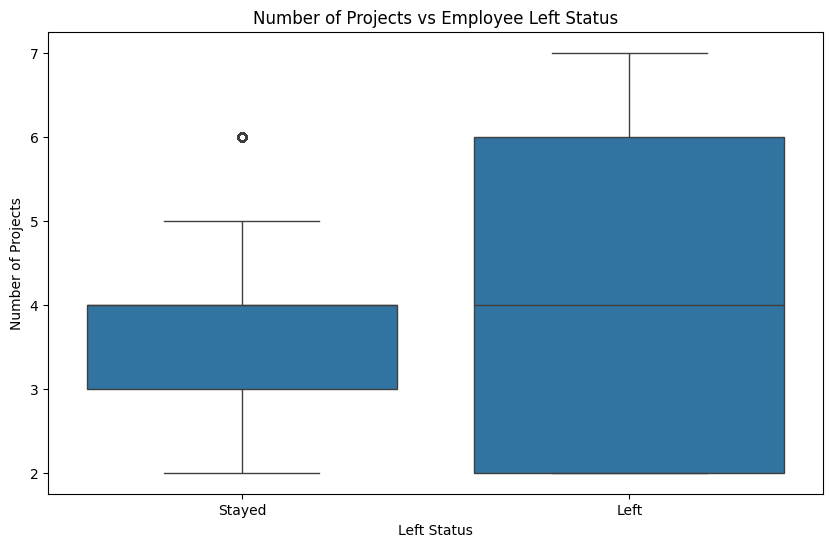

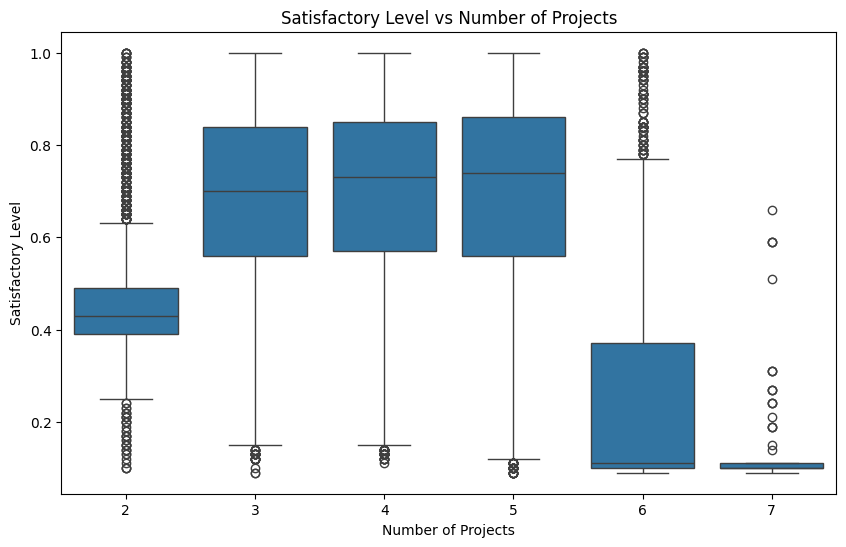

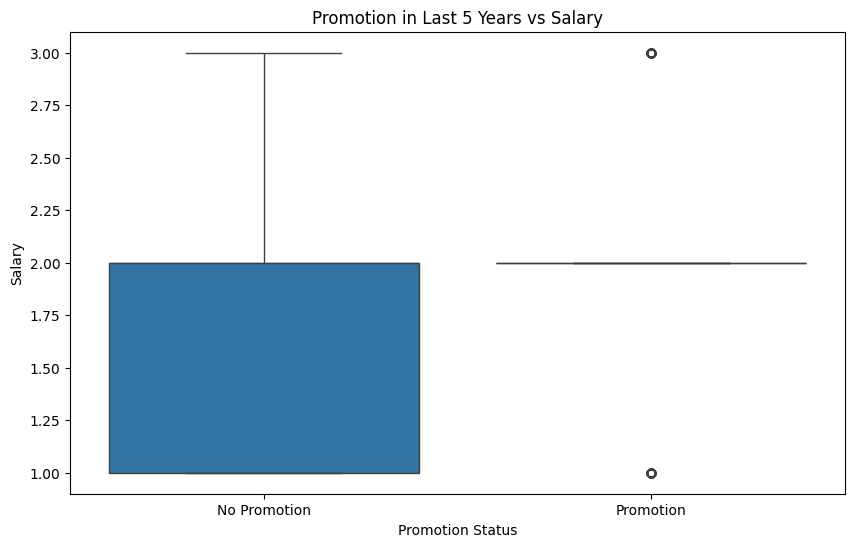

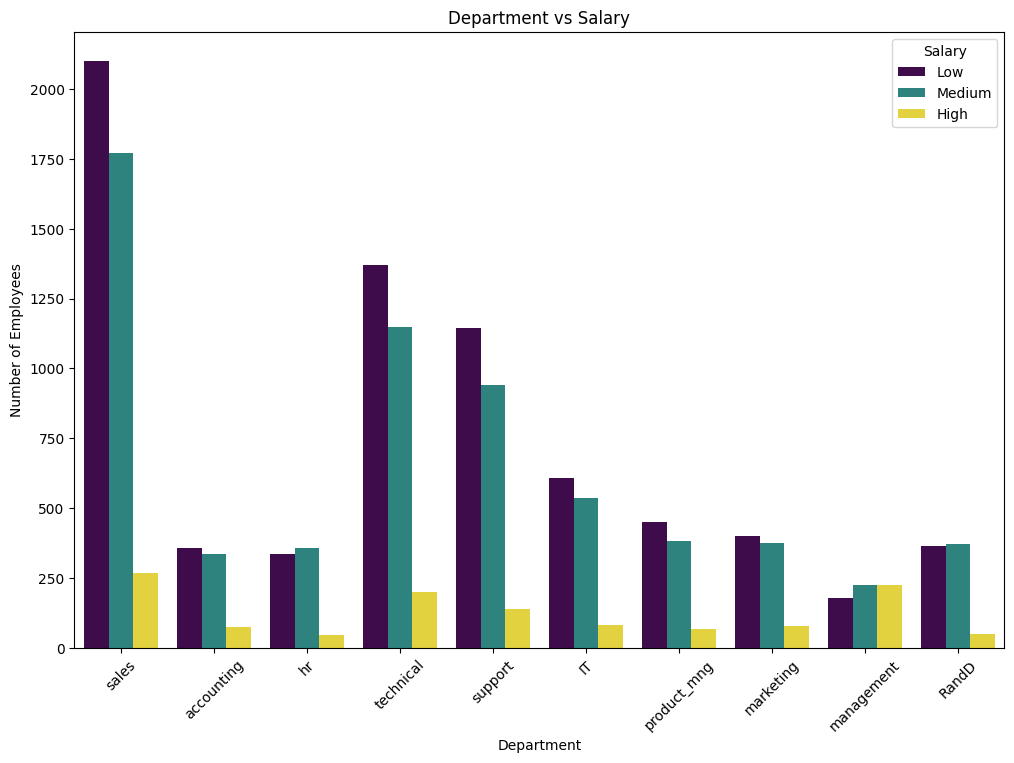

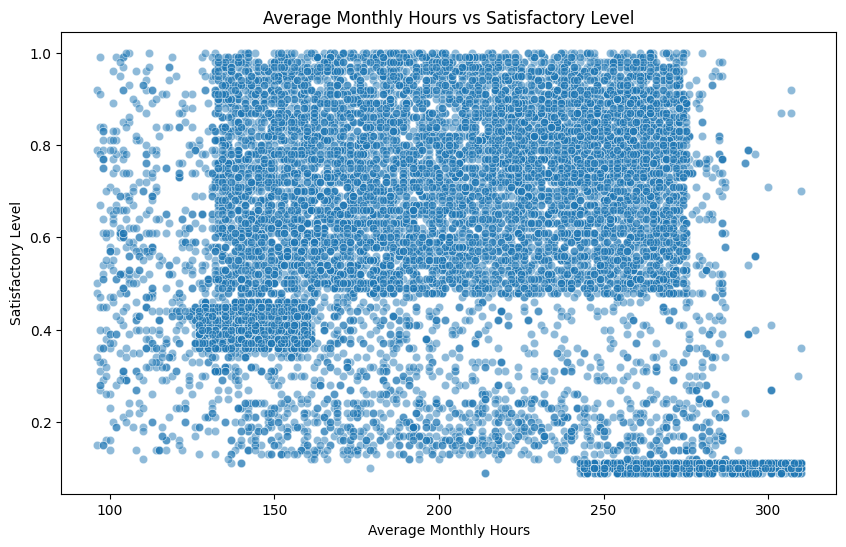

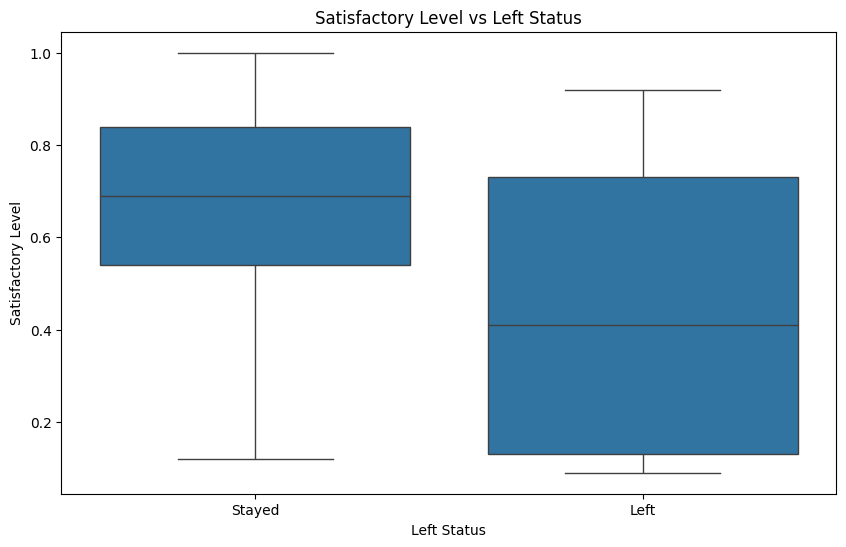

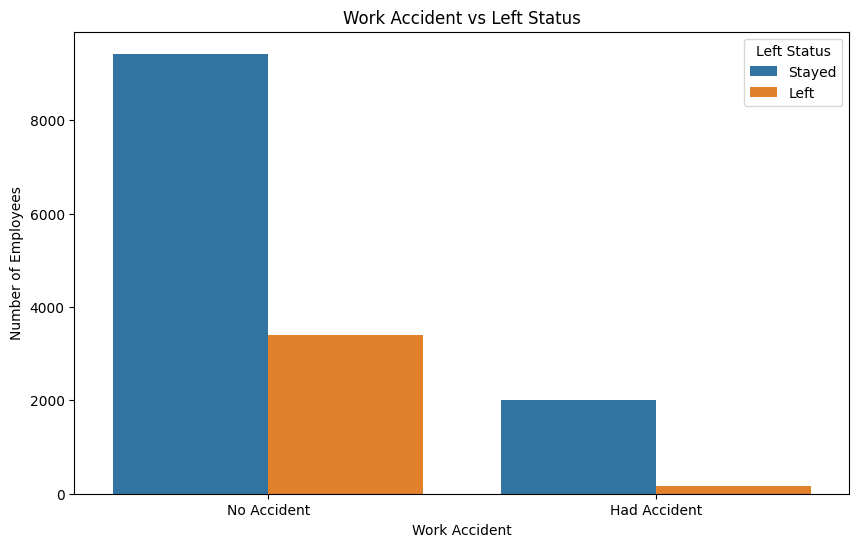

In [ ]:
# Step 4: Relationship Analysis & Visualization
print("\n--- Relationship Analysis & Visualization ---")

# No. of projects vs Salary
plt.figure(figsize=(10, 6))
sns.boxplot(x='salary', y='numberOfProjects', data=df)
plt.title('Number of Projects vs Salary')
plt.xticks(ticks=[1, 2, 3], labels=['Low', 'Medium', 'High'])
plt.xlabel('Salary')
plt.ylabel('Number of Projects')
plt.show()

# No. of project vs left
plt.figure(figsize=(10, 6))
sns.boxplot(x='left', y='numberOfProjects', data=df)
plt.title('Number of Projects vs Employee Left Status')
plt.xticks(ticks=[0, 1], labels=['Stayed', 'Left'])
plt.xlabel('Left Status')
plt.ylabel('Number of Projects')
plt.show()

# Satisfactory level vs No. of Projects
plt.figure(figsize=(10, 6))
sns.boxplot(x='numberOfProjects', y='satisfactoryLevel', data=df)
plt.title('Satisfactory Level vs Number of Projects')
plt.xlabel('Number of Projects')
plt.ylabel('Satisfactory Level')
plt.show()

# Promotion vs salary
plt.figure(figsize=(10, 6))
sns.boxplot(x='promotionInLast5years', y='salary', data=df)
plt.title('Promotion in Last 5 Years vs Salary')
plt.xticks(ticks=[0, 1], labels=['No Promotion', 'Promotion'])
plt.xlabel('Promotion Status')
plt.ylabel('Salary')
plt.show()

# Dept. vs salary
plt.figure(figsize=(12, 8))
sns.countplot(x='dept', hue='salary', data=df, palette='viridis')
plt.title('Department vs Salary')
plt.xticks(rotation=45)
plt.xlabel('Department')
plt.ylabel('Number of Employees')
plt.legend(title='Salary', labels=['Low', 'Medium', 'High'])
plt.show()

# Avge Monthly Hours vs satisfactory level
plt.figure(figsize=(10, 6))
sns.scatterplot(x='avgMonthlyHours', y='satisfactoryLevel', data=df, alpha=0.5)
plt.title('Average Monthly Hours vs Satisfactory Level')
plt.xlabel('Average Monthly Hours')
plt.ylabel('Satisfactory Level')
plt.show()

# Satisfactory level vs left
plt.figure(figsize=(10, 6))
sns.boxplot(x='left', y='satisfactoryLevel', data=df)
plt.title('Satisfactory Level vs Left Status')
plt.xticks(ticks=[0, 1], labels=['Stayed', 'Left'])
plt.xlabel('Left Status')
plt.ylabel('Satisfactory Level')
plt.show()

# Work accident vs left
plt.figure(figsize=(10, 6))
sns.countplot(x='workAccident', hue='left', data=df)
plt.title('Work Accident vs Left Status')
plt.xticks(ticks=[0, 1], labels=['No Accident', 'Had Accident'])
plt.xlabel('Work Accident')
plt.ylabel('Number of Employees')
plt.legend(title='Left Status', labels=['Stayed', 'Left'])
plt.show()

In [ ]:
# Step 5: Encoding and Standardizing for Machine Learning
print("\n--- Preparing Data for Logistic Regression ---")

# Convert the 'dept' column using one-hot encoding
df = pd.get_dummies(df, columns=['dept'], drop_first=True)

# Define X and y
X = df.drop('left', axis=1) # All columns except 'left' are features
y = df['left'] # 'left' is the target variable

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)

# Standardize the numerical features
numerical_features = ['satisfactoryLevel', 'lastEvaluation', 'numberOfProjects', 'avgMonthlyHours', 'timeSpent.company', 'salary']
scaler = StandardScaler()
X[numerical_features] = scaler.fit_transform(X[numerical_features])
print("\nNumerical features have been standardized.")


--- Preparing Data for Logistic Regression ---
Shape of X (features): (14999, 17)
Shape of y (target): (14999,)

Numerical features have been standardized.


In [ ]:
# Step 6: Split Data and Train Model
# [cite_start]Use 75% for training and 25% for testing [cite: 1, 2]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)
print("\nData has been split into training and testing sets.")
print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

# [cite_start]Use Logistic Regression [cite: 1, 2]
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)
print("\nLogistic Regression model has been trained.")


Data has been split into training and testing sets.
Training set shape: (11249, 17)
Testing set shape: (3750, 17)

Logistic Regression model has been trained.


In [ ]:
# Step 7: Model Evaluation
y_pred = model.predict(X_test)

# Confusion Matrix
print("\n--- Model Evaluation ---")
print("Confusion Matrix:")
cm = confusion_matrix(y_test, y_pred)
print(cm)

# Classification Report
print("\nClassification Report:")
cr = classification_report(y_test, y_pred)
print(cr)

# Accuracy Score
print("\nAccuracy Score:")
accuracy = accuracy_score(y_test, y_pred)
print(accuracy)


--- Model Evaluation ---
Confusion Matrix:
[[2660  178]
 [ 584  328]]

Classification Report:
              precision    recall  f1-score   support

           0       0.82      0.94      0.87      2838
           1       0.65      0.36      0.46       912

    accuracy                           0.80      3750
   macro avg       0.73      0.65      0.67      3750
weighted avg       0.78      0.80      0.77      3750


Accuracy Score:
0.7968
